## Here we will build ML project to predict Company Reviews between:
### {-1: negative, 0: neutral, 1: positive}

#### We will use two different appraches:
- Classeical NLP approach (Tf-IDF + classical ML models)
- pretrained encoder-transformer

## Libraries

In [61]:
!pip install emoji -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 15.6 MB/s eta 0:00:00


In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
import emoji
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,f1_score,recall_score,precision_score
from scipy.sparse import hstack
import numpy as np

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Load Data & investigation

In [79]:
df=pd.read_csv('CompanyReviews.csv')
df.head()

,Unnamed: 0,review_description,rating,company
0,0,رائع,1,talbat
1,1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,1,talbat
2,2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,-1,talbat
3,3,لماذا لا يمكننا طلب من ماكدونالدز؟,-1,talbat
4,4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,-1,talbat


In [80]:
df.drop('Unnamed: 0',axis=1,inplace=True)
df.head()

,review_description,rating,company
0,رائع,1,talbat
1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,1,talbat
2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,-1,talbat
3,لماذا لا يمكننا طلب من ماكدونالدز؟,-1,talbat
4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,-1,talbat


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40046 entries, 0 to 40045
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   review_description  40045 non-null  object
 1   rating              40046 non-null  int64 
 2   company             40046 non-null  object
dtypes: int64(1), object(2)
memory usage: 938.7+ KB


In [82]:
df.shape

(40046, 3)

In [83]:
df.isnull().sum()

,0
review_description,1
rating,0
company,0


In [84]:
df.dropna(inplace=True)
df.isnull().sum()

,0
review_description,0
rating,0
company,0


In [85]:
df.duplicated().sum()

np.int64(28)

In [86]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

## EDA

### Number of Ratings

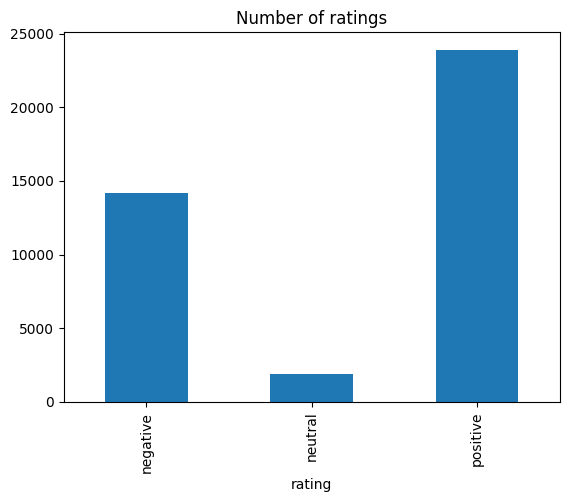

In [87]:
counts = df['rating'].value_counts().sort_index()

counts.plot(kind='bar')

plt.title('Number of ratings')
plt.xticks(ticks=[0, 1, 2], labels=['negative', 'neutral', 'positive'])

plt.show()

Imbalance classes

### Distribution of Classes

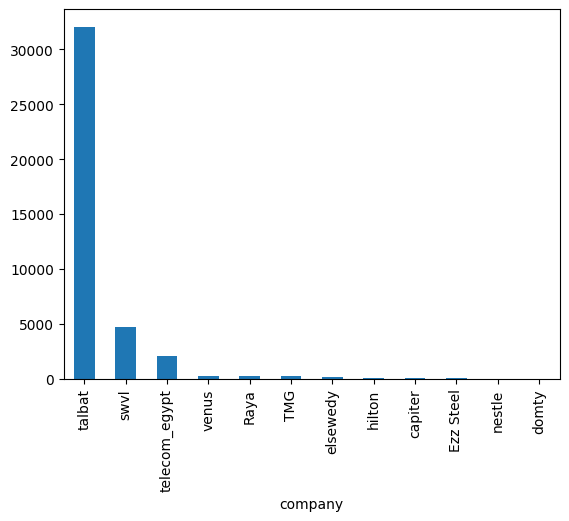

In [88]:
df['company'].value_counts().plot(kind='bar')
plt.show()

The reviews come from different Fields, almost all come from Food review (talabat)

### Detect Code Switching

In [89]:
def count_english_words(text):

    # Find all tokens that are fully English letters
    english_tokens = re.findall(r'[a-zA-Z]+', text)
    return len(english_tokens)

df['number_english_words'] = df['review_description'].apply(count_english_words)
df.head()

,review_description,rating,company,number_english_words
0,رائع,1,talbat,0
1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,1,talbat,0
2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,-1,talbat,0
3,لماذا لا يمكننا طلب من ماكدونالدز؟,-1,talbat,0
4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,-1,talbat,0


In [90]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
rating,40017.0,0.242422,0.945079,-1.0,-1.0,1.0,1.0,1.0
number_english_words,40017.0,0.149661,1.693183,0.0,0.0,0.0,0.0,97.0


In [91]:
df[df['number_english_words']==97]

,review_description,rating,company,number_english_words
35719,i have donlwded this app. on saturday2/3/2019s...,-1,swvl,97


In [92]:
df['is_have_english_words']=df['number_english_words'].apply(lambda x: 1 if x>0 else 0)

In [93]:
df['is_have_english_words'].value_counts()

,count
is_have_english_words,
0,38382
1,1635


it's about 4.25% of sentences have english words

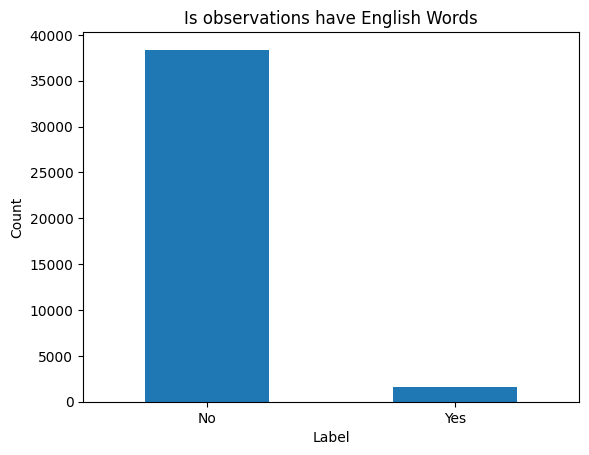

In [94]:
df['is_have_english_words'].value_counts().plot(kind='bar')
plt.title('Is observations have English Words')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'],rotation=0)
plt.show()

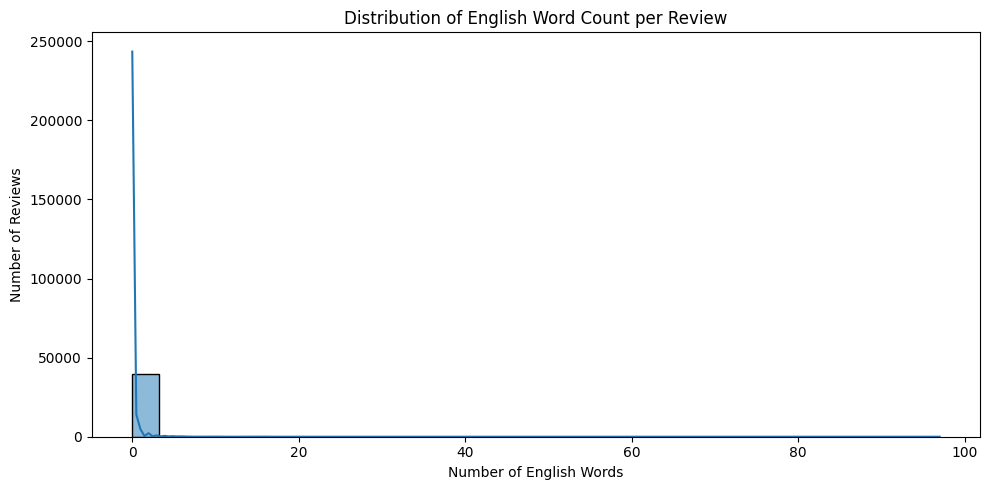

In [95]:
plt.figure(figsize=(10, 5))
sns.histplot(df['number_english_words'], bins=30, kde=True)

plt.title('Distribution of English Word Count per Review')
plt.xlabel('Number of English Words')
plt.ylabel('Number of Reviews')

plt.tight_layout()
plt.show()

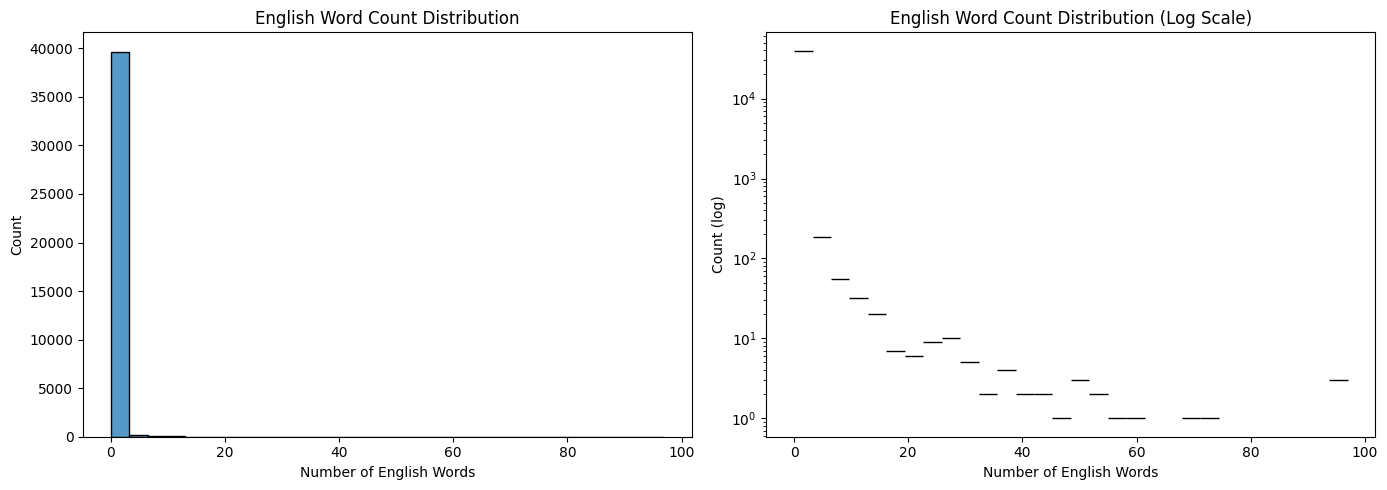

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normal scale
sns.histplot(df['number_english_words'], bins=30, kde=False, ax=axes[0])
axes[0].set_title('English Word Count Distribution')
axes[0].set_xlabel('Number of English Words')
axes[0].set_ylabel('Count')

# Log scale (better when data is skewed)
sns.histplot(df['number_english_words'], bins=30, kde=False, ax=axes[1], log_scale=(False, True))
axes[1].set_title('English Word Count Distribution (Log Scale)')
axes[1].set_xlabel('Number of English Words')
axes[1].set_ylabel('Count (log)')

plt.tight_layout()
# plt.savefig('plots/english_word_count_dist.png', dpi=150)
plt.show()

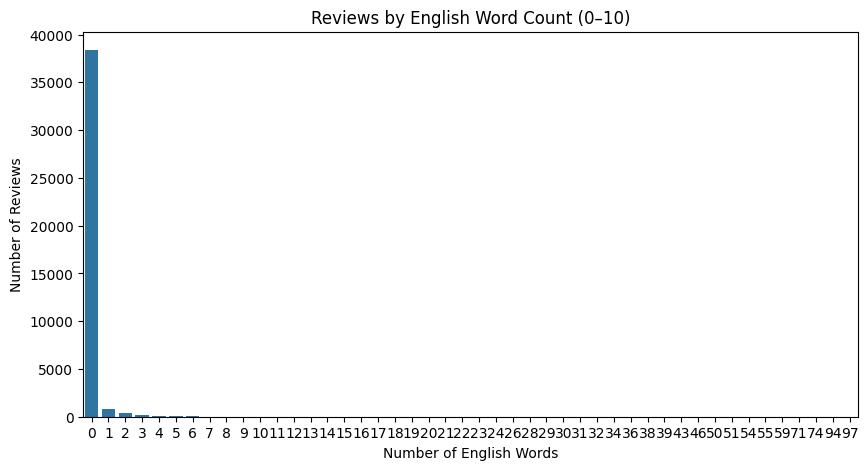

In [97]:
counts = df['number_english_words'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=counts.index, y=counts.values)
plt.title('Reviews by English Word Count (0–10)')
plt.xlabel('Number of English Words')
plt.ylabel('Number of Reviews')
plt.show()

In [98]:
df[df['number_english_words']==1]

,review_description,rating,company,number_english_words,is_have_english_words
43,اسعار أعلى بنسب تتجاوز ال٧٠٪ من المطاعم تجارب ...,-1,talbat,1,1
67,Wo 🙌🙌💋💋💋💋💋💋💙💙💙❤❤💖💖💖👍👍👍👌,1,talbat,1,1
81,ugg,1,talbat,1,1
120,Good,1,talbat,1,1
404,Jgc,1,talbat,1,1
...,...,...,...,...,...
39287,التطبيق عندي مش بيشتغل دايما كاتب opss علي اي ...,0,hilton,1,1
39364,بصراحه انا قضيت يوم ممتع thanks,1,hilton,1,1
39395,مع هذا ويتم تزوير Rk وتقليد السلك,0,elsewedy,1,1
39791,Yas,1,TMG,1,1


In [103]:
# 1. Word count
df['word_count'] = df['review_description'].apply(lambda x: len(x.split()))

# 2. Emoji count
df['emoji_count'] =  df['review_description'].apply(lambda x: emoji.emoji_count(x))

# 3. Punctuation count
df['punctuation_count'] =  df['review_description'].apply(
lambda x: sum(1 for c in x if c in '!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~')
)

# 4. Sentence count
df['sentence_count'] =  df['review_description'].apply(
lambda x: max(len(sent_tokenize(x)), 1) if x.strip() else 0
)

# 5. Average words per sentence
df['avg_words_per_sentence'] = df['word_count'] / df['sentence_count']

# ratio of english words to total words
df['english_ratio'] = df['number_english_words'] / df['word_count']



In [105]:
df.head()

,review_description,rating,company,number_english_words,is_have_english_words,word_count,emoji_count,punctuation_count,sentence_count,avg_words_per_sentence,english_ratio
0,رائع,1,talbat,0,0,1,0,0,1,1.0,0.0
1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,1,talbat,0,0,9,0,0,1,9.0,0.0
2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,-1,talbat,0,0,15,0,4,2,7.5,0.0
3,لماذا لا يمكننا طلب من ماكدونالدز؟,-1,talbat,0,0,6,0,0,1,6.0,0.0
4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,-1,talbat,0,0,15,0,0,1,15.0,0.0


In [106]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
rating,40017.0,0.242422,0.945079,-1.000000,-1.0,1.0,1.0,1.0
number_english_words,40017.0,0.149661,1.693183,0.000000,0.0,0.0,0.0,97.0
is_have_english_words,40017.0,0.040858,0.197963,0.000000,0.0,0.0,0.0,1.0
word_count,40017.0,9.375440,12.528210,1.000000,3.0,5.0,11.0,443.0
emoji_count,40017.0,0.476098,3.832018,0.000000,0.0,0.0,0.0,246.0
punctuation_count,40017.0,0.551316,7.766569,0.000000,0.0,0.0,0.0,495.0
sentence_count,40017.0,1.049854,0.444027,1.000000,1.0,1.0,1.0,46.0
avg_words_per_sentence,40017.0,8.896655,11.273583,0.333333,3.0,5.0,11.0,374.0
english_ratio,40017.0,0.030913,0.184469,0.000000,0.0,0.0,0.0,12.0


In [107]:
import re
import emoji

def decode_emojies(text):

    if not isinstance(text, str) or text.strip() == "":
        return ""

    # 1. Decode emojis to their meaning
    text = emoji.demojize(text, delimiters=(" ", " "))


    text = re.sub(r'(?<=[a-z])_(?=[a-z])', ' ', text)  # replace underscores between words

    # 2. Remove extra whitespace left after decoding
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [108]:
df['decoded_emojis'] = df['review_description'].apply(decode_emojies)
df.head()

,review_description,rating,company,number_english_words,is_have_english_words,word_count,emoji_count,punctuation_count,sentence_count,avg_words_per_sentence,english_ratio,decoded_emojis
0,رائع,1,talbat,0,0,1,0,0,1,1.0,0.0,رائع
1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,1,talbat,0,0,9,0,0,1,9.0,0.0,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...
2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,-1,talbat,0,0,15,0,4,2,7.5,0.0,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...
3,لماذا لا يمكننا طلب من ماكدونالدز؟,-1,talbat,0,0,6,0,0,1,6.0,0.0,لماذا لا يمكننا طلب من ماكدونالدز؟
4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,-1,talbat,0,0,15,0,0,1,15.0,0.0,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...


### See the heatmap to check if these features affected our target column (rating) or not

In [110]:
df.select_dtypes(include='number').columns

Index(['rating', 'number_english_words', 'is_have_english_words', 'word_count',
       'emoji_count', 'punctuation_count', 'sentence_count',
       'avg_words_per_sentence', 'english_ratio'],
      dtype='object')

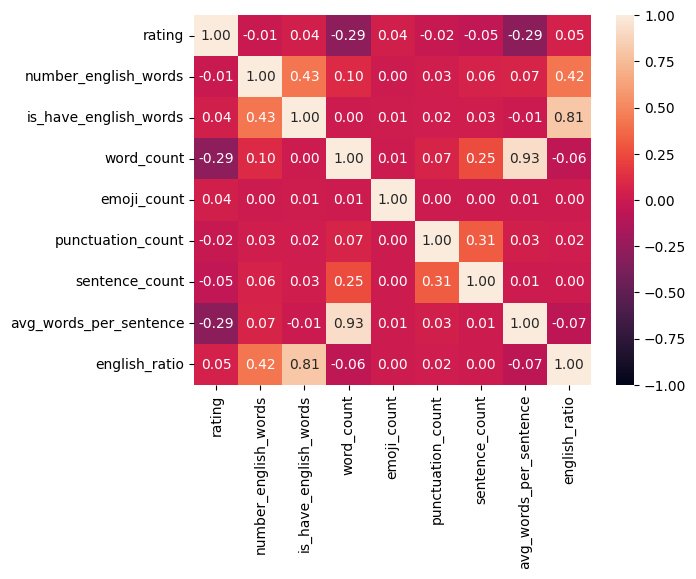

In [113]:
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True,fmt='.2f',vmin=-1,vmax=1)
plt.show()

avg_words_per_sentence and word_count have low correlation, unlike others don't correlate at all

For training we will select decoded_emojis feature only and rating column as target

In [114]:
df.to_csv('df_eda.csv',index=False)

In [115]:
pd.read_csv('df_eda.csv').head()

,review_description,rating,company,number_english_words,is_have_english_words,word_count,emoji_count,punctuation_count,sentence_count,avg_words_per_sentence,english_ratio,decoded_emojis
0,رائع,1,talbat,0,0,1,0,0,1,1.0,0.0,رائع
1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,1,talbat,0,0,9,0,0,1,9.0,0.0,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...
2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,-1,talbat,0,0,15,0,4,2,7.5,0.0,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...
3,لماذا لا يمكننا طلب من ماكدونالدز؟,-1,talbat,0,0,6,0,0,1,6.0,0.0,لماذا لا يمكننا طلب من ماكدونالدز؟
4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,-1,talbat,0,0,15,0,0,1,15.0,0.0,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...
